# Analysis 1: Mass–Radius Relation by Discovery Method

**Author:** Aradhya Haldikar  
**Date:** March 2026  
**Corresponding paper:** *A Self‑Directed Census: Analyzing 6,105 Confirmed Exoplanets from First Principles*  
**GitHub repository:** [https://github.com/Dhpla12/exoplanet-analysis](https://github.com/Dhpla12/exoplanet-analysis)

---

## About this analysis

This notebook reproduces **Section 3.5** of the paper. It examines how the mass–radius relationship differs for planets discovered by different methods (radial velocity, transit, direct imaging).

### Goals:
- Fetch confirmed exoplanet data from the NASA Exoplanet Archive.
- Apply a 30% uncertainty cut to select reliable mass and radius measurements.
- Plot mass vs. radius on a log–log scale, colored by discovery method.
- Fit a power law \( R \propto M^\alpha \) to each method group.
- Compare the exponents \(\alpha\) and intercepts to reveal detection biases.

### Data source:
- **Original data:** NASA Exoplanet Archive Planetary Systems Table (`ps`), DOI: [10.26133/NEA13](https://doi.org/10.26133/NEA13)
- **Filtered dataset:** Harvard Dataverse, DOI: [10.7910/DVN/WQGSNE](https://doi.org/10.7910/DVN/WQGSNE)

### Key result:
RV and transit planets share a similar slope (\(\alpha \approx 0.38\)), but differ in intercept, reflecting selection effects. Imaging planets (small sample) show a flat trend.

---

## How to use this notebook

1. Run all cells sequentially.
2. The first cell will display the plot and print the fitted parameters.
3. Figures and values can be directly compared to those in the paper.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.3 MB/s eta 0:00:00
Fetching confirmed planets data...
Total confirmed planets: 6128
Columns available: ['pl_name', 'pl_masse', 'pl_masseerr1', 'pl_masseerr2', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'discoverymethod', 'st_met', 'st_teff', 'pl_orbsmax']

Planets with both mass and radius quality (<30% uncertainty): 1119

Counts per method:
  Radial Velocity: 27
  Transit: 1079
  Imaging: 10


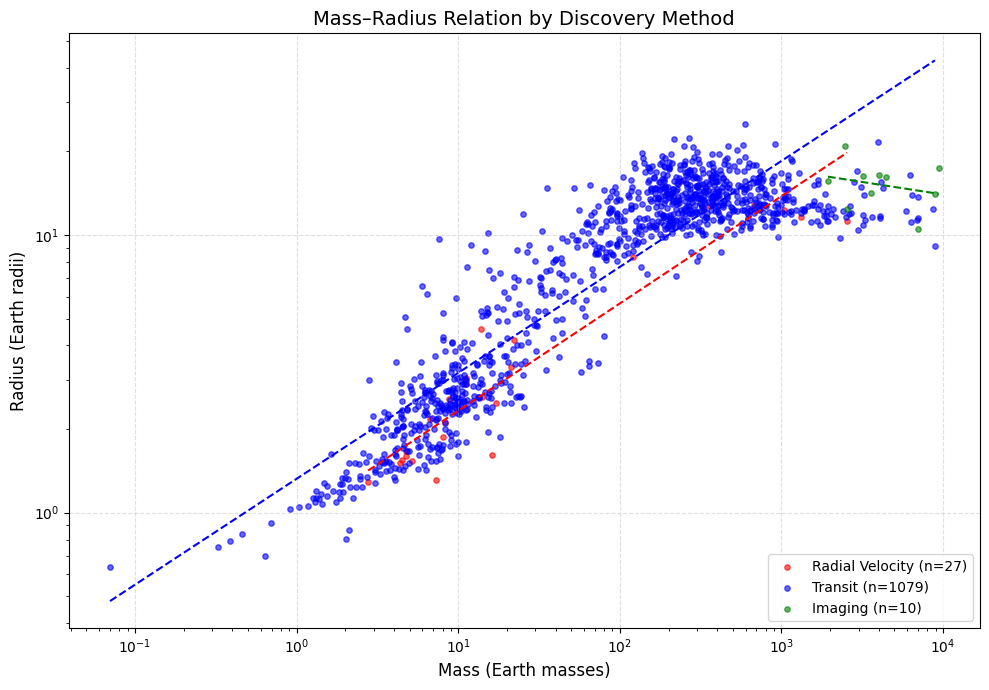


FITTED POWER‑LAW EXPONENTS (α) AND INTERCEPTS (β)
Form: log R = α log M + β   (R in Earth radii, M in Earth masses)

Radial Velocity (n=27):
  α = 0.386 ± 0.029
  β = -0.019 ± 0.047

Transit (n=1079):
  α = 0.381 ± 0.006
  β = 0.122 ± 0.012

Imaging (n=10):
  α = -0.090 ± 0.118
  β = 1.506 ± 0.428


In [1]:
# =============================================================================
# Analysis 1: Mass–Radius Relation by Discovery Method
# =============================================================================

#Install astroquery
!pip install astroquery --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

# 1. Fetch data with all necessary columns
print("Fetching confirmed planets data...")
df = NasaExoplanetArchive.query_criteria(
    table="ps",
    select="pl_name, pl_masse, pl_masseerr1, pl_masseerr2, pl_rade, pl_radeerr1, pl_radeerr2, discoverymethod, st_met, st_teff, pl_orbsmax",
    where="default_flag=1",
    cache=False
).to_pandas()

print(f"Total confirmed planets: {len(df)}")
print(f"Columns available: {df.columns.tolist()}\n")

# 2. Quality cuts (same as before)
mass_ok = df['pl_masse'].notna() & df['pl_masseerr1'].notna() & df['pl_masseerr2'].notna()
rade_ok = df['pl_rade'].notna() & df['pl_radeerr1'].notna() & df['pl_radeerr2'].notna()

df['mass_frac_err'] = np.nan
df.loc[mass_ok, 'mass_frac_err'] = np.maximum(df.loc[mass_ok, 'pl_masseerr1'], df.loc[mass_ok, 'pl_masseerr2']) / df.loc[mass_ok, 'pl_masse']

df['rade_frac_err'] = np.nan
df.loc[rade_ok, 'rade_frac_err'] = np.maximum(df.loc[rade_ok, 'pl_radeerr1'], df.loc[rade_ok, 'pl_radeerr2']) / df.loc[rade_ok, 'pl_rade']

df['mass_quality'] = df['mass_frac_err'] < 0.3
df['rade_quality'] = df['rade_frac_err'] < 0.3

# Keep only planets with good mass AND radius for this analysis
good_both = df['mass_quality'] & df['rade_quality']
df_good = df[good_both].copy()
print(f"Planets with both mass and radius quality (<30% uncertainty): {len(df_good)}")

# 3. Separate by discovery method (focus on main ones)
methods_of_interest = ['Radial Velocity', 'Transit', 'Imaging']
df_methods = {method: df_good[df_good['discoverymethod'] == method] for method in methods_of_interest}

# Print counts
print("\nCounts per method:")
for method, subset in df_methods.items():
    print(f"  {method}: {len(subset)}")

# 4. Power‑law fit function (log space)
def power_law(logM, alpha, beta):
    return alpha * logM + beta   # log R = α log M + β

# 5. Plot and fit
plt.figure(figsize=(10, 7))
colors = {'Radial Velocity': 'red', 'Transit': 'blue', 'Imaging': 'green'}
fit_results = {}

for method in methods_of_interest:
    subset = df_methods[method]
    if len(subset) < 5:
        print(f"\n{method}: insufficient data for fit (n={len(subset)})")
        fit_results[method] = None
        continue

    logM = np.log10(subset['pl_masse'])
    logR = np.log10(subset['pl_rade'])

    # Fit
    popt, pcov = curve_fit(power_law, logM, logR)
    alpha, beta = popt
    perr = np.sqrt(np.diag(pcov))

    fit_results[method] = {'alpha': alpha, 'alpha_err': perr[0], 'beta': beta, 'beta_err': perr[1], 'n': len(subset)}

    # Scatter points
    plt.scatter(subset['pl_masse'], subset['pl_rade'],
                color=colors[method], alpha=0.6, s=15,
                label=f"{method} (n={len(subset)})")

    # Plot fit line
    x_fit = np.logspace(np.log10(subset['pl_masse'].min()), np.log10(subset['pl_masse'].max()), 50)
    logx_fit = np.log10(x_fit)
    logy_fit = alpha * logx_fit + beta
    plt.plot(x_fit, 10**logy_fit, color=colors[method], linestyle='--', linewidth=1.5)

# Plot formatting
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Mass (Earth masses)', fontsize=12)
plt.ylabel('Radius (Earth radii)', fontsize=12)
plt.title('Mass–Radius Relation by Discovery Method', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 6. Print fit results
print("\n" + "="*60)
print("FITTED POWER‑LAW EXPONENTS (α) AND INTERCEPTS (β)")
print("Form: log R = α log M + β   (R in Earth radii, M in Earth masses)")
print("="*60)
for method, res in fit_results.items():
    if res is None:
        continue
    print(f"\n{method} (n={res['n']}):")
    print(f"  α = {res['alpha']:.3f} ± {res['alpha_err']:.3f}")
    print(f"  β = {res['beta']:.3f} ± {res['beta_err']:.3f}")

### Bootstrap Uncertainty Estimation

Because the sample sizes, especially for radial velocity (N=27) and imaging (N=10), are small, the formal least‑squares uncertainties may be underestimated. To obtain more robust confidence intervals, we perform bootstrap resampling (10,000 iterations). In each iteration, we randomly resample the data for each method with replacement, refit the power law, and record the slope ($\alpha$) and intercept ($\beta$). The 68% confidence intervals are then taken as the 16th and 84th percentiles of the bootstrap distributions.

In [2]:
# ===== BOOTSTRAP UNCERTAINTIES FOR MASS–RADIUS FITS =====
from sklearn.utils import resample

n_bootstrap = 10000
methods = ['Radial Velocity', 'Transit', 'Imaging']
bootstrap_results = {method: {'alpha': [], 'beta': []} for method in methods}

for method in methods:
    subset = df_methods[method]
    if len(subset) < 5:
        continue

    logM = np.log10(subset['pl_masse']).values
    logR = np.log10(subset['pl_rade']).values

    for _ in range(n_bootstrap):
        # Resample with replacement
        idx = resample(range(len(logM)), replace=True, n_samples=len(logM))
        logM_boot = logM[idx]
        logR_boot = logR[idx]

        # Fit
        try:
            popt, _ = curve_fit(power_law, logM_boot, logR_boot)
            bootstrap_results[method]['alpha'].append(popt[0])
            bootstrap_results[method]['beta'].append(popt[1])
        except:
            continue

# Compute 68% confidence intervals (1-sigma)
print("\n" + "="*60)
print("BOOTSTRAP UNCERTAINTIES (68% confidence intervals)")
print("="*60)
for method in methods:
    if len(bootstrap_results[method]['alpha']) == 0:
        continue
    alpha_arr = np.array(bootstrap_results[method]['alpha'])
    beta_arr = np.array(bootstrap_results[method]['beta'])

    alpha_lo, alpha_hi = np.percentile(alpha_arr, [16, 84])
    beta_lo, beta_hi = np.percentile(beta_arr, [16, 84])

    print(f"\n{method}:")
    print(f"  α = {np.mean(alpha_arr):.3f}  [{alpha_lo:.3f}, {alpha_hi:.3f}]")
    print(f"  β = {np.mean(beta_arr):.3f}  [{beta_lo:.3f}, {beta_hi:.3f}]")
    print(f"  (based on {len(alpha_arr)} bootstrap samples)")


BOOTSTRAP UNCERTAINTIES (68% confidence intervals)

Radial Velocity:
  α = 0.392  [0.357, 0.426]
  β = -0.025  [-0.066, 0.017]
  (based on 10000 bootstrap samples)

Transit:
  α = 0.381  [0.375, 0.388]
  β = 0.122  [0.110, 0.135]
  (based on 10000 bootstrap samples)

Imaging:
  α = -0.100  [-0.230, 0.026]
  β = 1.542  [1.089, 2.007]
  (based on 10000 bootstrap samples)
